# Estadistica Aplicada

# PIA - Serie de Tiempo

## Equipo - Conecta Mente
* Alejandro Luna Alejos - 1874612
* Jazmin Alessandra Gonzalez Rodriguez - 1989943
* Brayan Alejandro Estrada Rodriguez -
* Humberto Ceniceros Preciado - 1903633

**Grupo: 042**

## **1. Añadirás una primera parte a la notebook llamada introducción. Hablaras de la serie de tiempo que te toco analizar: ¿qué mide? ¿la frecuencia de los datos? ¿se observa alguna tendencia? Y se puede añadir la gráfica de la serie.**

# Introducción

### ¿Que mide?

La serie de tiempo mide el PIB, donde los registros se mantienen desde el año de 1993 hasta el 2023.

### ¿La frecuencia de los datos?

La serie se matiene con una frecuencia de medicion mensual.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm


In [36]:
df_IGAE = pd.read_excel('base_PIA.xlsx')
df_IGAE

,mes,IGAE
0,1993/01,55.434714
1,1993/02,56.456934
2,1993/03,58.900516
3,1993/04,57.135808
4,1993/05,57.891816
...,...,...
363,2023/04,100.490496
364,2023/05,106.113244
365,2023/06,104.550513
366,2023/07,102.780837


In [37]:
df_IGAE.isnull().sum()

mes     0
IGAE    0
dtype: int64

In [38]:
df_IGAE['mes'] = pd.to_datetime(df_IGAE['mes'], format='%Y/%m')
df_IGAE = df_IGAE.set_index('mes')
df_IGAE = df_IGAE.asfreq('MS')
df_IGAE.index

DatetimeIndex(['1993-01-01', '1993-02-01', '1993-03-01', '1993-04-01',
               '1993-05-01', '1993-06-01', '1993-07-01', '1993-08-01',
               '1993-09-01', '1993-10-01',
               ...
               '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01',
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01'],
              dtype='datetime64[ns]', name='mes', length=368, freq='MS')

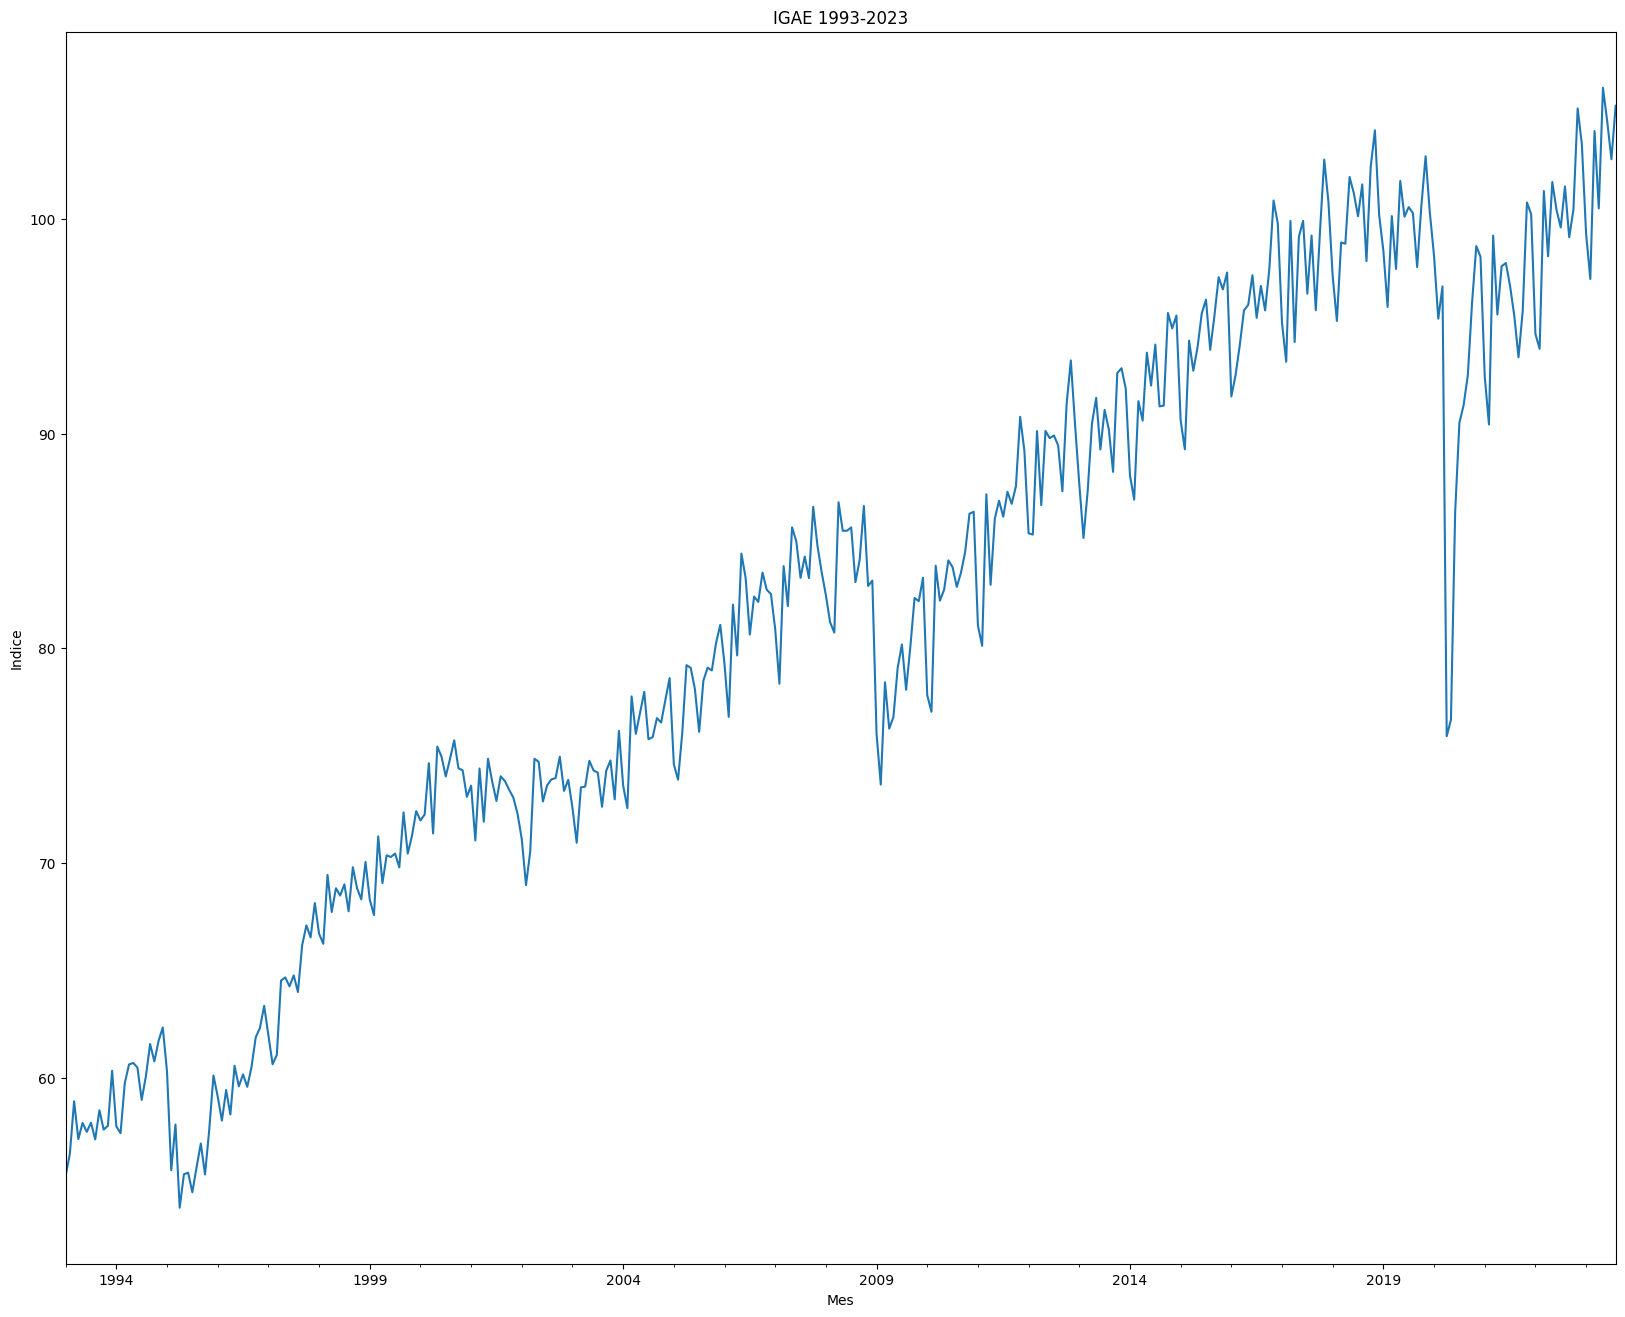

In [39]:
df_IGAE['IGAE'].plot(figsize=(20,16))
plt.title('IGAE 1993-2023')
plt.ylabel('Indice')
plt.xlabel('Mes')
plt.show();

## **2. Comenta acerca de si se observa cierta estacionalidad en la serie, en que meses aumenta la variable ¿por qué?, en qué meses disminuye la variable¿por qué? ¿hay efecto estacional?**


No se puede observar algun tipo de estacionalidad en la serie de tiempo, por lo que se podria considerar que es no estacionaria, al ir aumentando y disminuyendo dependiendo de la oportunidad laborar y de como se esta trabajando, va variando segun la temporada del año que sea.

In [40]:
df_IGAE.head(12)

,IGAE
mes,
1993-01-01,55.434714
1993-02-01,56.456934
1993-03-01,58.900516
1993-04-01,57.135808
1993-05-01,57.891816
1993-06-01,57.475444
1993-07-01,57.902360
1993-08-01,57.123924
1993-09-01,58.482065


Comenta acerca de si se observa cierta estacionalidad en la serie, en que
meses aumenta la variable ¿por qué?, en qué meses disminuye la variable
¿por qué? ¿hay efecto estacional?

## **3. Uno los propósitos fundamentales del análisis de series de tiempo es el pronóstico, es decir, “anticipar valores futuros de la variable”. Comenta para quién es importante conocer el pronóstico de la serie de tiempo que analizaras y por qué es importante conocer el pronóstico de dicha serie de tiempo.** 


El indice es util para saber como evoluciona el secto economico a corto plazo, de esa forma sabiendo que tan bien o mal se estara y de que manera se deben tomar decisiones, por ello es importante tanto para la poblacion comun pero principalmente compañias quienes deban saber que movimientos deben realizar, ya sea para no verse significativamente perjudicados y mejor beneficiados.

## **4. Añade las estadísticas descriptivas de la serie de tiempo.**

In [41]:
df_IGAE.describe()

,IGAE
count,368.000000
mean,81.476113
std,13.700711
min,53.941797
25%,72.341739
50%,82.281634
75%,93.917631
max,106.113244


## **5. Para ver mejor el comportamiento de la variable aplica un promedio móvil centrado**

In [42]:
df_IGAE['Media movil-5 Meses']=df_IGAE['IGAE'].rolling(5).mean()
df_IGAE


,IGAE,Media movil-5 Meses
mes,,
1993-01-01,55.434714,NaN
1993-02-01,56.456934,NaN
1993-03-01,58.900516,NaN
1993-04-01,57.135808,NaN
1993-05-01,57.891816,57.163958
...,...,...
2023-04-01,100.490496,100.917893
2023-05-01,106.113244,101.444752
2023-06-01,104.550513,102.490843


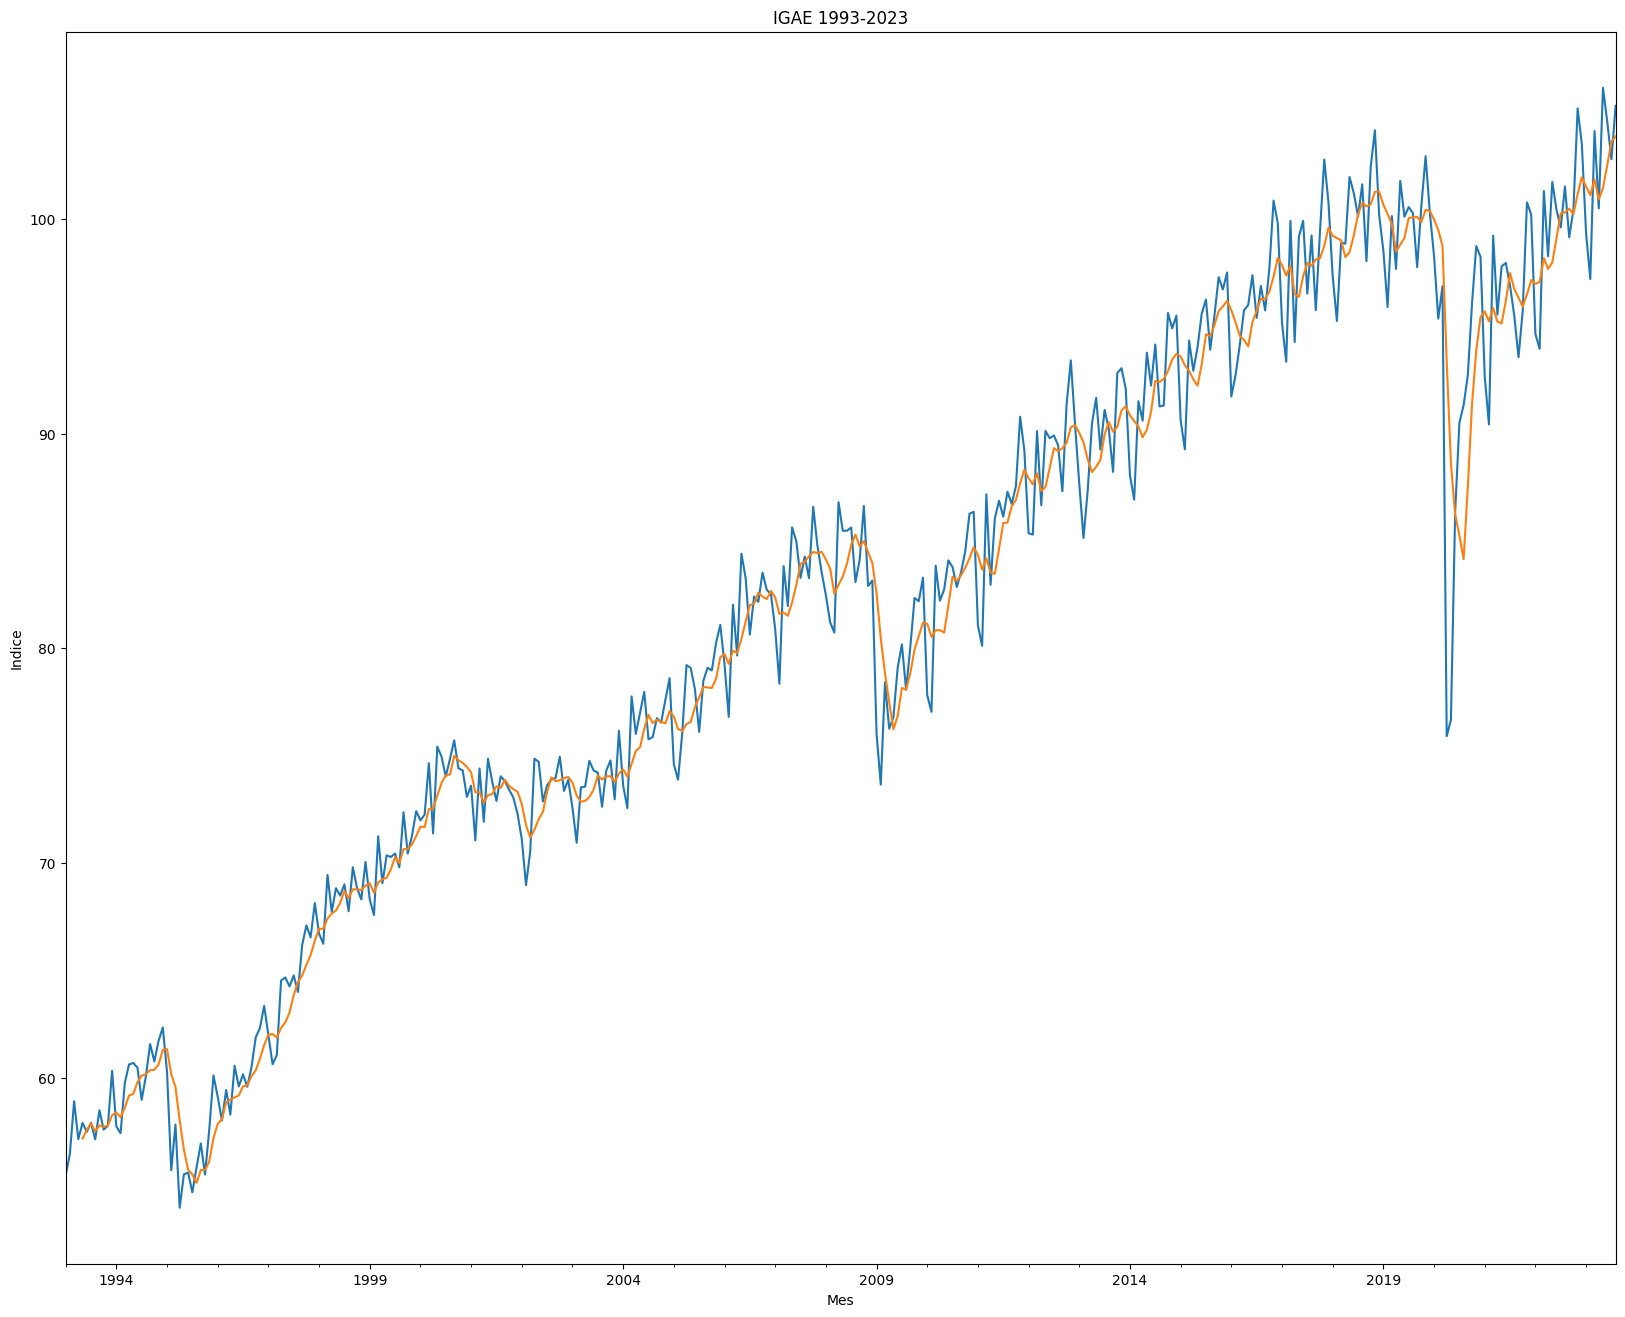

In [43]:
df_IGAE['IGAE'].plot(figsize=(20,16),label = 'IGAE')
df_IGAE['Media movil-5 Meses'].plot(label = 'media movil 5 meses')
plt.title('IGAE 1993-2023')
plt.ylabel('Indice')
plt.xlabel('Mes')
plt.show();

## **6. Utiliza la descomposición estacional, para obtener el componente estacional, y la serie desestacionalizada.**

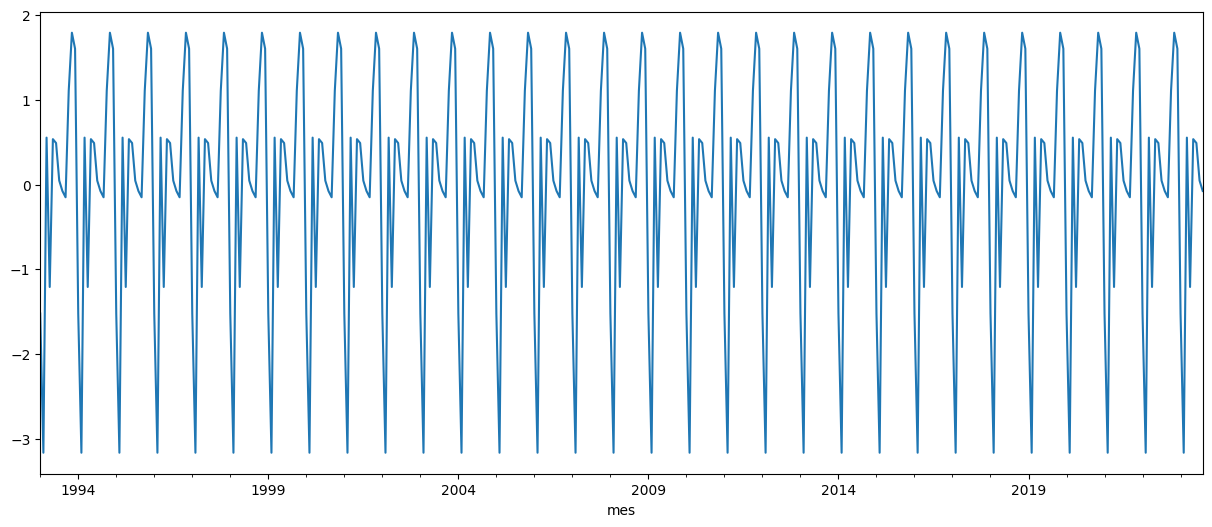

In [44]:
seasonal = seasonal_decompose(df_IGAE['IGAE'], model = 'add').seasonal
seasonal.plot(figsize = (15,6))
plt.show()

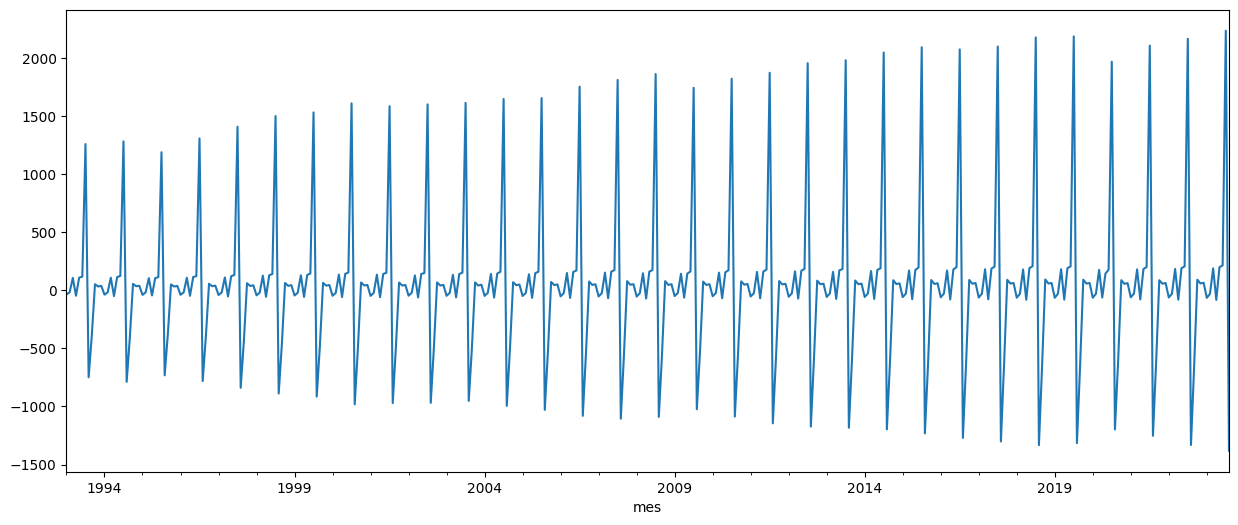

In [45]:
df_IGAE['Desest'] = df_IGAE['IGAE']/seasonal
df_IGAE['Desest'].plot(figsize = (15,6))
plt.show()

## **7. Utiliza la serie original para hacer el análisis ARIMA**

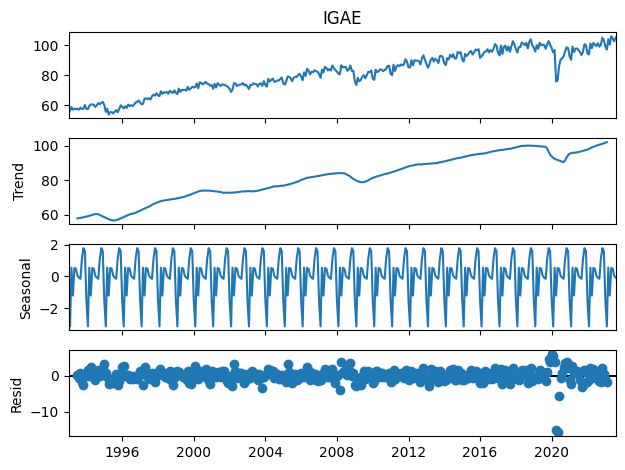

In [46]:
Arima = seasonal_decompose(df_IGAE['IGAE'],model='add')
Arima.plot()
plt.show()

## **8. Realiza una prueba de raíz unitaria para verificar si este proceso es estacionario (sino es estacionario conviértelo en estacionario).**

In [47]:
adf = adfuller(df_IGAE['IGAE'])
pvalue = adf[1]
pvalue.round(2)

0.8

No se rechaza Ho, la serie sobre el PIB es no estacionaria.

In [48]:
df_IGAE['IGAE_diff'] = df_IGAE['IGAE'].diff()
p_adf = adfuller(df_IGAE['IGAE_diff'].dropna())
pvalue1 = p_adf[1]
pvalue1.round(2)

0.0

Como el pvalue < 0.05, se rechaza H0 y las primerias diferencias de la serie de usuarios de Metrorrey es una serie estacionaria.

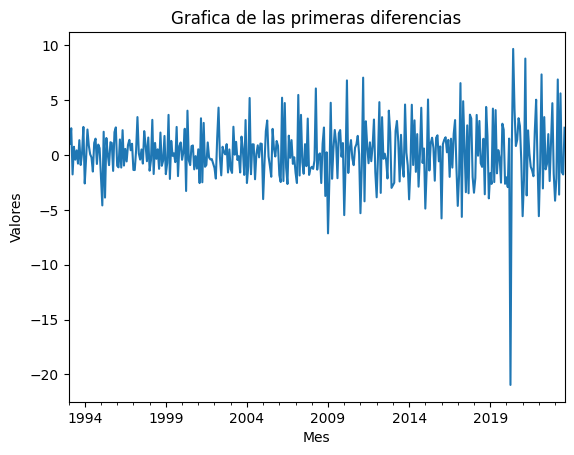

In [49]:
df_IGAE['IGAE_diff'].plot()
plt.title('Grafica de las primeras diferencias')
plt.xlabel('Mes')
plt.ylabel('Valores')
plt.show()

## **9. Con el proceso estacionario, realiza las gráficas de autocorrelación (ACF) y autocorrelación parcial (PACF) y señala como se interpretan.**


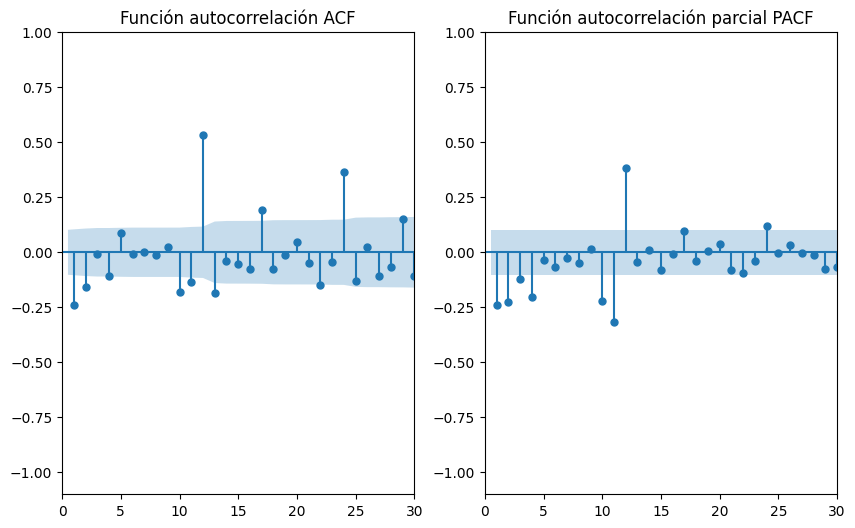

In [50]:
ig, ax= plt.subplots(1,2, figsize=(10,6))
# 1
plot_acf(df_IGAE['IGAE_diff'].dropna(), zero = False, lags = 30, ax=ax[0], title = 'Función autocorrelación ACF')
ax[0].set_ylim(-1.1)
ax[0].set_xlim(0,30)
# 2
plot_pacf(df_IGAE['IGAE_diff'].dropna(), zero = False, lags = 30, ax=ax[1], title = 'Función autocorrelación parcial PACF')
ax[1].set_ylim(-1.1)
ax[1].set_xlim(0,30)
plt.show()

## **10. Utilizando el código auto_arima y elige un criterio para seleccionar el modelo, ya sea el criterio de akaike (AIC) o el criterio bayesiano de información (BIC)**

In [51]:
pm.auto_arima(df_IGAE['IGAE'],
              start_p=1,
              start_q=1,
              m = 12,
              max_p=7,
              max_q=7,
              seasonal=True,
              start_P=1,
              start_Q=1,
              max_P=7,
              max_Q=7,
              information_criterion='aic')

ARIMA(order=(1, 1, 1), scoring_args={}, seasonal_order=(6, 0, 1, 12),
      suppress_warnings=True)

  ## **11. Estima el modelo ARIMA que hayas elegidoe interpreta los coeficientes**

In [52]:
model = ARIMA(df_IGAE['IGAE'],
            order = (1,1,1),
            seasonal_order = (6,0,1,12))
results = model.fit()
print(results.summary())

c:\Users\jgonzalez\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                    SARIMAX Results                                     
Dep. Variable:                             IGAE   No. Observations:                  368
Model:             ARIMA(1, 1, 1)x(6, 0, 1, 12)   Log Likelihood                -753.375
Date:                          Sun, 12 Nov 2023   AIC                           1526.750
Time:                                  16:23:42   BIC                           1565.803
Sample:                              01-01-1993   HQIC                          1542.267
                                   - 08-01-2023                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8341      0.030     27.643      0.000       0.775       0.893
ma.L1         -0.9698      0.023    -42.911      0.

## **12. Utiliza el modelo estimado para hacer pronósticos, y pronóstica uno, dos, tres, cuatro y cinco periodos. Recuerda que el pronóstico tiene que estar en la escala de la variable original.**

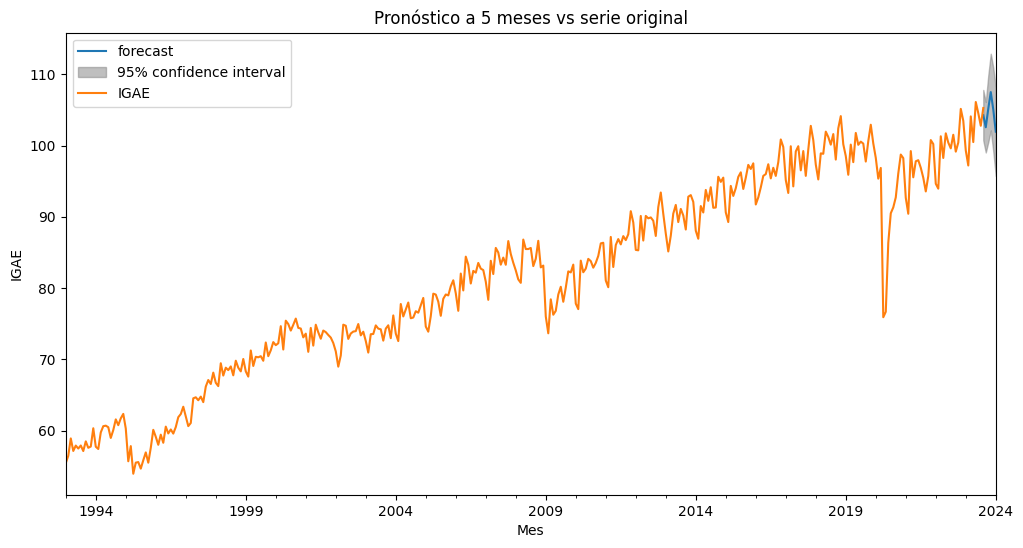

In [53]:
plot_predict(results, '2023-08-01', '2024-01-01')
df_IGAE['IGAE'].plot(figsize=(12,6))
plt.xlim('1993-01-01', '2024-01-01')
plt.title('Pronóstico a 5 meses vs serie original')
plt.legend(loc='upper left')
plt.ylabel('IGAE')
plt.xlabel('Mes')
plt.legend()
plt.show()

In [54]:
forecast = results.get_forecast(steps=5)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [55]:
inicio = '2023-08-01'
fin= '2024-01-01'
pronostico_valor = forecast_mean[inicio:fin]
pronostico_int = forecast_ci.loc[inicio:fin]

In [56]:
pronostico_IGAE = pd.DataFrame({
    'pronóstico ': pronostico_valor,
    'limite inferior': pronostico_int.iloc[:,0],
    'limite superior': pronostico_int.iloc[:,1]
})
pronostico_IGAE

,pronóstico,limite inferior,limite superior
2023-09-01,102.570665,99.029424,106.111906
2023-10-01,105.171693,100.491028,109.852359
2023-11-01,107.506669,102.122975,112.890363
2023-12-01,105.052478,99.187919,110.917038
2024-01-01,101.950600,95.739098,108.162103
